# Exact Binary Apodizer Design as a Linear Program

The [Augmented Lagrangian](AugmentedLagrangian_Optimization.ipynb) how-to enforces a dark-hole contrast constraint with an iterative outer loop, and needs a carefully-tuned schedule to reach a binary design. This how-to attacks the *same monochromatic, field-constrained* design problem from the other end: as an **exact linear program** solved by `scipy`.

The key observation: for an **amplitude-apodized** pupil every propagation in the coronagraph is linear, so the dark-hole field is an *affine* function of the apodizer vector,

$$E_{\mathrm{dh}} = A x + b,$$

and the field-box contrast constraint from the AL notebook ($|\mathrm{Re}\,a| \le s$, $|\mathrm{Im}\,a| \le s$ with $a = E/\sqrt{\mathrm{norm}}$ and $s = \sqrt{c/2}$) is **linear** in $x$. Throughput $\sum_i x_i$ is linear too. The design problem

> maximize throughput  subject to  (field box in the dark hole),  $0 \le x \le 1$

is therefore *literally a linear program* — the formulation behind the classic shaped-pupil and apodizer designs of Vanderbei, Spergel & Kasdin, Carlotti *et al.* (2011), and the SCDA APLC studies. Solving it exactly buys two things the AL loop cannot promise:

1. **The global optimum** of the continuous problem — with a certificate of infeasibility if the contrast is simply unreachable, instead of an optimizer that quietly stalls.
2. **Near-binary solutions with no binarization machinery at all**: an optimal *basic* (vertex) solution has at most as many fractional entries as there are active constraint rows — at most $4m$ for $m$ dark-hole pixels. When the pupil has many more pixels than that ($n \gg 4m$), the design comes out overwhelmingly binary automatically.

The price is memory and CPU time: $A$ is a dense $m \times n$ complex matrix, and `scipy`'s HiGHS solver runs on the CPU. This is the right tool for monochromatic designs at moderate resolution; the AL loop remains the tool for GPU-scale and broadband problems, and — as the finishing step below shows — the two combine naturally.

## Instrument setup

The same optical layout as the other how-tos (circular entrance pupil, annular focal-plane mask, annular Lyot stop), at a deliberately CPU-friendly scale — the LP constraint matrix is dense, so the pupil sampling is chosen to keep it a few hundred MB. Nothing here needs cupy: `scipy`'s LP runs on the CPU regardless.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from time import perf_counter

from prysm.propagation import prepare_executor

from dygdug.masks import Pupil, FPM, ImgSamplingSpec, annular_mask, knife_edge_mask
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph

# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 256
Nfoc = 256
wvl = 1
fno = 13.66
efl = fno * circumscribed_diameter
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4  # the "oversampling"

# Variable (amplitude-apodized) entrance pupil
pupil = VariablePupil.circle(Dpup=circumscribed_diameter, Npup=Npup, mode="amplitude")

executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=8,
)

lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.1 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2,
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

## Dark hole, requirement, and the variable/constraint balance

A 180°, 3–8 λ/D dark hole (the apodizer is real, so Hermitian symmetry darkens the mirror half automatically) and a `1e-7` contrast requirement.

One ratio to check **before** committing to the LP route: with $m$ dark-hole pixels there are $4m$ inequality rows ($\pm$Re, $\pm$Im), and LP theory bounds the number of fractional pixels in a vertex solution by the number of *active* rows. You want

$$n \gg 4m$$

so the guaranteed-binary majority dominates. If $4m \gtrsim n$ (coarse pupil grids, huge dark holes) the vertex can be fractional almost everywhere, and no rounding step will rescue it — enlarge `Npup` or shrink the dark hole first.

In [32]:
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=3, owa=8, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)

dh_idx = np.flatnonzero(np.asarray(dark_hole).astype(bool).ravel())
pup_idx = pupil._mask_idx
n = pupil.n_params  # optimizable pupil pixels
m = dh_idx.size     # constrained dark-hole pixels

contrast_req = 1e-8

print(f"n = {n} pupil pixels, m = {m} dark-hole pixels -> 4m = {4*m} constraint rows")
print(f"n / 4m = {n / (4*m):.1f}  (want >> 1)")

n = 51429 pupil pixels, m = 619 dark-hole pixels -> 4m = 2476 constraint rows
n / 4m = 20.8  (want >> 1)


## The affine model: one adjoint propagation per dark-hole pixel

`Coronagraph.reverse` is the exact adjoint of `forward`, so seeding it with a unit impulse at dark-hole pixel $i$ returns the conjugate of row $i$ of $A$ — the sensitivity of that pixel's field to every pupil pixel. $m$ reverse propagations build the whole Jacobian, which is much cheaper than $n$ forward propagations since $m \ll n$.

The offset $b$ is easy to miss: anti-aliased pixels on the aperture rim have transmission strictly between 0 and 1, are **not** part of the optimizable mask (`VariablePupil` only optimizes `data == 1` pixels), yet still diffract. $b$ is simply the dark-hole field with the apodizer zeroed. We then verify $E = Ax + b$ against the real propagator to machine precision — if this assert ever fires, the LP would be solving the wrong problem.

In [33]:
t0 = perf_counter()
A = np.empty((m, n), dtype=complex)
Ebar = np.zeros((Nfoc, Nfoc), dtype=complex)
for k, i in enumerate(dh_idx):
    Ebar.ravel()[i] = 1.0
    coro.reverse(Ebar, wvl, include_fpm=True)
    A[k] = np.conj(coro.adjoint_at_entrance_pupil.ravel()[pup_idx])
    Ebar.ravel()[i] = 0.0
print(f"Jacobian ({m} adjoint propagations): {perf_counter()-t0:.1f} s, "
      f"{A.nbytes/1e6:.0f} MB")

# Offset from the frozen (anti-aliased rim) pixels: the field with x = 0.
pupil.update(np.zeros(n))
b = coro.forward(wvl, include_fpm=True).ravel()[dh_idx].copy()

# Contrast normalization: direct (no-FPM) peak of the open pupil.
pupil.update(np.ones(n))
norm = float(np.max(np.abs(coro.forward(wvl, include_fpm=False)) ** 2))

# Verify E_dh = A x + b against the real propagator.
rng = np.random.default_rng(0)
x_test = rng.uniform(0, 1, n)
pupil.update(x_test)
E_ref = coro.forward(wvl, include_fpm=True).ravel()[dh_idx]
err = np.max(np.abs(A @ x_test + b - E_ref)) / np.max(np.abs(E_ref))
print(f"affine model max relative error: {err:.1e}")
assert err < 1e-12, "affine model does not match the propagator"


Jacobian (619 adjoint propagations): 3.9 s, 509 MB
affine model max relative error: 2.3e-15


## Can a binary mask even hold this contrast? The granularity check

Before solving anything, the Jacobian answers a question no optimizer can fix afterwards: **is the pupil sampling fine enough for a *binary* design at this contrast?** Flipping one pixel between 0 and 1 changes the normalized dark-hole amplitude by that pixel's Jacobian entry — its *field quantum*. A binary design assembles the dark hole out of these quanta, so the amplitude budget $s = \sqrt{c/2}$ must be several times the largest quantum, or the final rounding of even a handful of pixels blows the budget.

(At `Npup=128` with this dark hole, $s(10^{-8})$ is *half* the largest quantum — a binary design at 1e-8 is physically impossible on that grid, no matter the algorithm. That failure is invisible until you check.)

In [34]:
s_req = np.sqrt(contrast_req / 2)
quantum = np.abs(A) / np.sqrt(norm)  # per-pixel amplitude quantum, normalized

print(f"amplitude budget s: {s_req:.1e}")
print(f"pixel field quantum: max {quantum.max():.1e}, median {np.median(quantum):.1e}")
print(f"s / max quantum: {s_req / quantum.max():.1f}  (want >~ 3)")

amplitude budget s: 7.1e-05
pixel field quantum: max 3.9e-05, median 2.4e-05
s / max quantum: 1.8  (want >~ 3)


## Assemble and solve the LP

Normalizing by the direct peak ($M = A/\sqrt{\mathrm{norm}}$, $\beta = b/\sqrt{\mathrm{norm}}$), the field box is four stacked row blocks,

$$\pm\mathrm{Re}(Mx) \le s \mp \mathrm{Re}(\beta), \qquad \pm\mathrm{Im}(Mx) \le s \mp \mathrm{Im}(\beta),$$

and we minimize $-\mathbf{1}^T x$ with HiGHS. Two practical notes:

- We solve **at the requirement**, not tighter. Deeper targets make HiGHS drastically slower (a 4× tighter target took ~15× longer in our tests), and a safety margin does not buy what you might hope — the finishing step below handles binarization feasibility properly instead.
- `linprog` returns a **vertex** solution, so almost all pixels land *exactly* on 0 or 1 (up to solver tolerance); no thresholding was involved in that statement.

In [ ]:
from scipy.optimize import linprog

rn = 1 / np.sqrt(norm)
M, boff = A * rn, b * rn
A_ub = np.vstack([M.real, -M.real, M.imag, -M.imag])
b_ub = s_req + np.concatenate([-boff.real, boff.real, -boff.imag, boff.imag])
print(f"LP: {A_ub.shape[0]} rows x {A_ub.shape[1]} cols ({A_ub.nbytes/1e6:.0f} MB)")

t0 = perf_counter()
res = linprog(-np.ones(n), A_ub=A_ub, b_ub=b_ub, bounds=(0, 1), method="highs")
print(f"solve: {perf_counter()-t0:.0f} s, status {res.status}, {res.message}")
assert res.status == 0, "infeasible: this contrast is unreachable for this geometry"

x_lp = res.x.copy()
tol = 1e-9
x_lp[x_lp <= tol] = 0.0
x_lp[x_lp >= 1 - tol] = 1.0
frac = np.flatnonzero((x_lp > 0) & (x_lp < 1))

print(f"throughput (mean transmission): {x_lp.mean():.4f}")
print(f"fractional pixels: {frac.size}/{n} ({frac.size/n:.2%}); LP bound was {4*m}")

LP: 2476 rows x 28913 cols (573 MB)


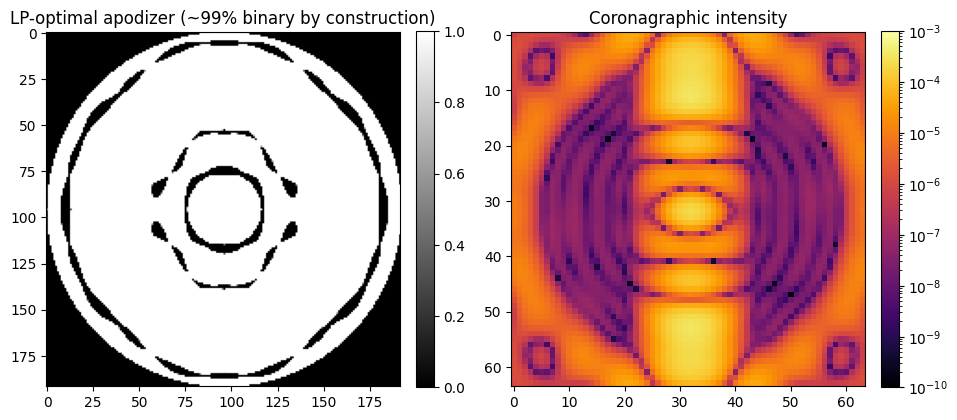

LP design dark-hole max contrast: 8.69e-08 (requirement 1e-07)


In [ ]:
pupil.update(x_lp)
I_lp = np.abs(coro.forward(wvl, include_fpm=True)) ** 2 / norm

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("LP-optimal apodizer (~99% binary by construction)")
im0 = ax[0].imshow(pupil.data, cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(I_lp, cmap="inferno", norm=LogNorm(vmin=1e-10, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

print(f"LP design dark-hole max contrast: {I_lp.ravel()[dh_idx].max():.2e} "
      f"(requirement {contrast_req:.0e})")

## Finish the last fractional pixels with the AL pin ladder

The remaining fractional pixels cannot simply be thresholded: they carry real field cancellation, and hard-rounding ~100 of them perturbs the dark hole coherently — in our tests by an order of magnitude in contrast. They also cannot be handed to a solver *alone*: with every binary pixel frozen, ~100 degrees of freedom cannot repair the perturbation their own rounding creates (we found the reduced problem infeasible even as a mixed-integer program).

What works is exactly the **fix-and-release rounding** from the [Augmented Lagrangian](AugmentedLagrangian_Optimization.ipynb) how-to, warm-started at the LP optimum: `model.pin(threshold)` collapses decided pixels onto their bounds, and a few matrix-free AL steps let *all* remaining free pixels restore the contrast around them before the next, looser pin. The LP supplies the globally-optimal layout and a feasible, nearly-binary start; the AL supplies a finisher whose repair capacity is the whole pupil, not just the gray residue.

In [ ]:
from prysm.x.optym import PrysmLBFGSB
from dygdug.coropt import AugmentedLagrangian

model = AugmentedLagrangian(
    coro=coro,
    optimizer=PrysmLBFGSB,
    dark_hole=dark_hole,
    wvl=[wvl],
    contrast=contrast_req,
    x0=x_lp.copy(),                   # warm start at the LP optimum
    lower_bounds=np.zeros(n),
    upper_bounds=np.ones(n),
    constraint_kind="scaled-field",   # O(1) residuals, as in the AL how-to
    normalize_throughput=True,
    throughput_weight=10.0,
    penalty=1.0,
    penalty_growth=2.0,
    optimizer_kwargs={"maxls": 50},
)

t0 = perf_counter()
# Converge the multipliers on the LP design before any pinning.
for _ in range(15):
    _, info = model.step(inner_steps=100, apply_relaxation=False)
print(f"warmup: violation {info['max_violation']:.2e}  ({perf_counter()-t0:.0f} s)")

for eps in [0.02, 0.05, 0.1, 0.2, 0.35, 0.5]:
    pin_info = model.pin(threshold=eps)
    if pin_info["n_free"] > 0:
        for _ in range(4):
            _, info = model.step(inner_steps=150, apply_relaxation=False)
    print(f"eps={eps:4.2f}: free {pin_info['n_free']:5d} "
          f"violation {model.violation():.2e}  ({perf_counter()-t0:.0f} s)")

x_binary = model.x

warmup: violation 4.24e-04  (19 s)
eps=0.02: free   226 violation 8.02e-02  (30 s)
eps=0.05: free    53 violation 8.90e-02  (45 s)
eps=0.10: free    42 violation 8.34e-02  (59 s)
eps=0.20: free    30 violation 9.06e-02  (72 s)
eps=0.35: free    12 violation 2.19e-01  (86 s)
eps=0.50: free     0 violation 4.96e-01  (86 s)


## Verify the binary design

Every pixel is now pinned to a bound, so the design is binary *by construction* — but the last pins traded some contrast, so the verdict comes from re-propagating and checking against the requirement. If it misses, the two levers are the granularity ratio (finer `Npup`) and the pin schedule (more AL repair steps per rung, smaller final rungs).

strictly binary: True
mean transmission (throughput): 0.9051 (LP continuous optimum was 0.9053)
requirement:  1.0e-07
binary design: mean 3.65e-08  max 1.41e-07  [MISS]


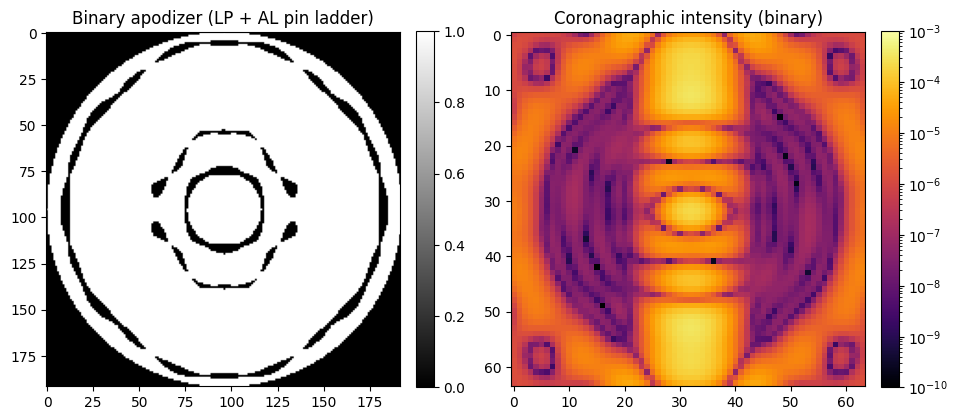

In [ ]:
print(f"strictly binary: {bool(np.all((x_binary == 0) | (x_binary == 1)))}")
print(f"mean transmission (throughput): {float(x_binary.mean()):.4f} "
      f"(LP continuous optimum was {x_lp.mean():.4f})")

pupil.update(x_binary)
I_bin = np.abs(coro.forward(wvl, include_fpm=True)) ** 2 / norm
max_I = I_bin.ravel()[dh_idx].max()

print(f"requirement:  {contrast_req:.1e}")
print(f"binary design: mean {I_bin.ravel()[dh_idx].mean():.2e}  max {max_I:.2e}  "
      f"[{'PASS' if max_I <= contrast_req else 'MISS'}]")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Binary apodizer (LP + AL pin ladder)")
im0 = ax[0].imshow(pupil.data, cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity (binary)")
im1 = ax[1].imshow(I_bin, cmap="inferno", norm=LogNorm(vmin=1e-10, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Scaling this up, and when to use which tool

- **Memory is the binding constraint.** `A_ub` is dense `4m x n` float64. Fold pupil symmetries first (a left-right symmetric design halves $n$; two-fold symmetry quarters it — the Vanderbei-school designs all do this), then consider float32 for the constraint matrix.
- **Building $A$ is cheap and GPU-friendly.** The $m$ adjoint propagations are trivially parallel; with the cupy backend, build on-device and transfer once (`scipy` needs the matrix on the host).
- **Deeper targets make HiGHS much slower.** Solve at the requirement; don't reflexively add margin.
- **Broadband designs** stack one `4m x n` block per wavelength — the LP stays exact, rows grow linearly.
- **Run the two checks before anything else**: the variable/constraint balance $n \gg 4m$ and the granularity ratio $s / \max_{ij} |A_{ij}|/\sqrt{\mathrm{norm}} \gtrsim 3$. Together they predict whether a near-binary vertex exists and whether *any* binary design can hold the contrast.
- **Division of labor**: the LP gives the exact continuous optimum and a certificate; the AL loop scales to GPU-sized, broadband, non-amplitude problems. The hybrid shown here — LP for the layout, AL pin ladder for the binary finish — is stronger than either alone, and equally good as an `x0` strategy: solve the LP at moderate resolution, then hand it to the `AugmentedLagrangian` at full resolution.

## Recap

- For amplitude apodizers the dark-hole field is **affine** in the design, $E = Ax + b$, so throughput-maximal design under the field-box constraint is an **exact linear program** — no penalty weights, no multiplier schedules, no binarization annealing.
- Build $A$ with **one adjoint propagation per dark-hole pixel**, don't forget the offset $b$ from the anti-aliased rim pixels, and verify the affine model against `forward` to machine precision.
- Check $n \gg 4m$ (vertex mostly binary) and the **granularity ratio** $s \gg$ pixel field quantum (a binary design is physically possible) before solving.
- The LP vertex is ~99% binary automatically; finish the fractional residue with the **AL fix-and-release pin ladder**, warm-started at the LP optimum, and verify the strictly-binary result against the requirement.